In [1]:
from langchain_openai import ChatOpenAI
import os
llm = ChatOpenAI(
    openai_api_key=os.getenv("OPENAI_API_KEY", ""),
    temperature=0,
    model="gpt-4",
    streaming=True,
    verbose=True,
)

In [2]:
output = llm.invoke("hi")
output.content

'Hello! How can I assist you today?'

In [3]:
os.environ['HF_TOKEN']=os.getenv("HF_TOKEN")

In [4]:
# Config the embedding model
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("hi"))


d:\PROJECT_PRACTISE_DIRS\AGENTICAI\py_ve_3.11.4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


384

In [5]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [6]:
loader=DirectoryLoader("data2",glob="./*.txt",loader_cls=TextLoader)


In [7]:
docs=loader.load()


In [8]:
docs
docs[0].page_content


"ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP â€“ Size, Composition, and Global Share\nAs of 2024, the United Statesâ€™ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ranks 2nd). The U.S. GDP per capita is also among the high

In [9]:
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

In [10]:
new_docs=text_splitter.split_documents(documents=docs)


In [11]:
new_docs


[Document(metadata={'source': 'data2\\usa.txt'}, page_content='ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='innovation, global trade, and financial

In [12]:
doc_string=[doc.page_content for doc in new_docs]


In [13]:
doc_string

['ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy',
 'The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,',
 'It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a',
 'a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.',
 'innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.',
 'U.S. GDP â€“ Size, Composition, and Global Share',
 'As of 2024, the United Statesâ€™ nominal GDP is estimated to be around $28 trillion USD, accounting for appr

In [14]:
len(doc_string)


56

In [15]:
db=Chroma.from_documents(new_docs,embeddings)


TypeError: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates

In [ ]:
retriever=db.as_retriever(search_kwargs={"k": 3})


In [ ]:
retriever.invoke("industrial growth of usa?")


[Document(metadata={'source': 'data2\\usa.txt'}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administrationâ€™s Inflation'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy'),
 Document(metadata={'source': 'data2\\usa.txt'}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

In [ ]:
import operator
from pydantic import BaseModel,Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

In [ ]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description='Reasoning behind topic selection')

In [ ]:
from langchain.output_parsers import PydanticOutputParser


In [ ]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser)


In [ ]:
parser.get_format_instructions()


'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

In [ ]:
class AgentState(TypedDict):
    message: Annotated[Sequence[BaseMessage], operator.add]

In [ ]:
Agentstate = {}

In [ ]:
Agentstate['messages']=['hi, how are you?']

In [ ]:
Agentstate['messages'].append('I am fine, thanks!')

In [ ]:
Agentstate['messages'].append('Okay, what about you?')

In [ ]:
type(Agentstate)

dict

In [ ]:
def function_1(state:AgentState):
    pass

In [ ]:
def function_2(state:AgentState):
    pass

In [ ]:
def function_3(state:AgentState):
    pass

In [ ]:
def router(state:AgentState):
    pass

In [ ]:
from langgraph.graph import StateGraph,END


In [ ]:
workflow=StateGraph(AgentState)


In [ ]:
workflow.add_node("Supervisor",function_1)


In [ ]:
workflow.add_node("RAG",function_2)


In [ ]:
workflow.add_node("LLM",function_3)


In [ ]:
workflow.set_entry_point("Supervisor")


In [ ]:
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

In [ ]:
workflow.add_edge("RAG",END)
workflow.add_edge("LLM",END)

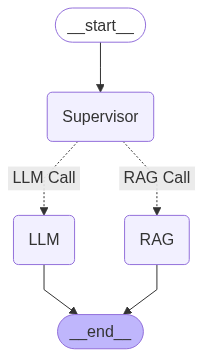

In [ ]:
workflow.compile()


In [ ]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI

# 1. Define state using TypedDict
class GraphStateData(TypedDict):
    input: str
    summary: Optional[str]
    hindi_summary: Optional[str]
    heading: Optional[str]

# 2. Functions
llm = ChatOpenAI()

def summarize(state: GraphStateData) -> dict:
    summary = llm.predict(f"Summarize this:\n\n{state['input']}")
    return {"summary": summary}

def translate(state: GraphStateData) -> dict:
    hindi = llm.predict(f"Translate to Hindi:\n\n{state['summary']}")
    return {"hindi_summary": hindi}

def generate_heading(state: GraphStateData) -> dict:  # Renamed function
    heading = llm.predict(f"Generate a heading for:\n\n{state['hindi_summary']}")
    return {"heading": heading}

# 3. Build graph
graph_builder = StateGraph(GraphStateData)
graph_builder.add_node("summarize", summarize)
graph_builder.add_node("translate", translate)
graph_builder.add_node("generate_heading", generate_heading) 

graph_builder.set_entry_point("summarize")
graph_builder.add_edge("summarize", "translate")
graph_builder.add_edge("translate", "generate_heading")  # Updated edge
graph_builder.set_finish_point("generate_heading")       # Updated finish point

graph = graph_builder.compile()

# 4. Run the graph
result = graph.invoke({"input": "Tell about Modi"})
print(result["heading"])  # This is the state key, remains unchanged


नरेंद्र मोदी: भारत का सक्रिय प्रधानमंत्री


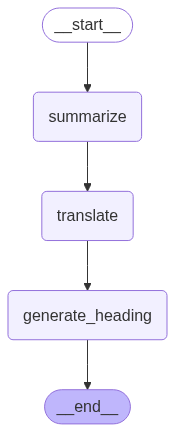

In [30]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


# Conditional WorkFlow

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI
from langchain.prompts import ChatPromptTemplate

# Shared state
class GraphState(TypedDict):
    query: str
    category: Literal["billing", "tech", "general"]

# LLM router setup
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
router_prompt = ChatPromptTemplate.from_template("""
Classify the customer query into one category:
- billing
- tech
- general
Return ONLY the category name.

Query: {query}
""")

def route_with_llm(state: GraphState):
    response = llm.invoke(router_prompt.format_messages(query=state["query"]))
    state["category"] = response.content.strip().lower()
    return state

# Agent nodes
def billing_agent(state: GraphState):
    print("💰 Billing issue:", state["query"])
    return state

def tech_agent(state: GraphState):
    print("🛠 Tech issue:", state["query"])
    return state

def general_agent(state: GraphState):
    print("📌 General query:", state["query"])
    return state

# Build graph
graph = StateGraph(GraphState)
graph.add_node("router", route_with_llm)
graph.add_node("billing", billing_agent)
graph.add_node("tech", tech_agent)
graph.add_node("general", general_agent)

graph.add_conditional_edges(
    "router",
    lambda state: state["category"],
    {
        "billing": "billing",
        "tech": "tech",
        "general": "general",
    }
)

graph.set_entry_point("router")
app = graph.compile()

# Test
app.invoke({"query": "My internet bill has extra charges"})


C:\Users\Adari Shanmukh\AppData\Local\Temp\ipykernel_18692\3585185885.py:12: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


💰 Billing issue: My internet bill has extra charges


{'query': 'My internet bill has extra charges', 'category': 'billing'}

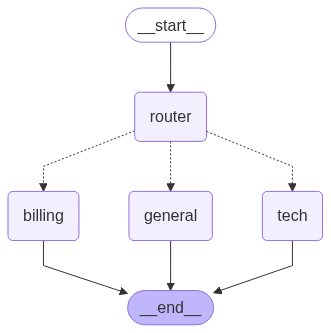

In [3]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# Parallelism WorkFlow

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI

# -----------------------------
# Shared state
# -----------------------------
class GraphState(TypedDict):
    query: str
    two_multiplier: int
    three_multiplier: int
    four_multiplier: int
    final_result: int

# LLM setup
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# -----------------------------
# Entry node
# -----------------------------
def query_input(state: GraphState):
    # Just pass the query along to the next nodes
    return {"query": state["query"]}

# -----------------------------
# Agent nodes
# -----------------------------
def number2_multiplier(state: GraphState):
    resp = llm.predict(f"Take the number {state['query']} and multiply it by 2. Only return the number.")
    return {"two_multiplier": int(resp.strip())}

def number3_multiplier(state: GraphState):
    resp = llm.predict(f"Take the number {state['query']} and multiply it by 3. Only return the number.")
    return {"three_multiplier": int(resp.strip())}

def number4_multiplier(state: GraphState):
    resp = llm.predict(f"Take the number {state['query']} and multiply it by 4. Only return the number.")
    return {"four_multiplier": int(resp.strip())}

def final_total(state: GraphState):
    total = state["two_multiplier"] + state["three_multiplier"] + state["four_multiplier"]
    return {"final_result": total}

# -----------------------------
# Build graph
# -----------------------------
graph = StateGraph(GraphState)

graph.add_node("query_input", query_input)
graph.add_node("number2_multiplier", number2_multiplier)
graph.add_node("number3_multiplier", number3_multiplier)
graph.add_node("number4_multiplier", number4_multiplier)
graph.add_node("final_total", final_total)

# Fan out from query → multipliers
graph.add_edge("query_input", "number2_multiplier")
graph.add_edge("query_input", "number3_multiplier")
graph.add_edge("query_input", "number4_multiplier")

# Merge multipliers → final
graph.add_edge(["number2_multiplier", "number3_multiplier", "number4_multiplier"], "final_total")

# Define entry/finish
graph.set_entry_point("query_input")
graph.set_finish_point("final_total")

# -----------------------------
# Compile and Run
# -----------------------------
workflow = graph.compile()

result = workflow.invoke({"query": "5"})
print('result',result)


result {'query': '5', 'two_multiplier': 10, 'three_multiplier': 15, 'four_multiplier': 20, 'final_result': 45}


In [10]:
print(result["final_result"])


45


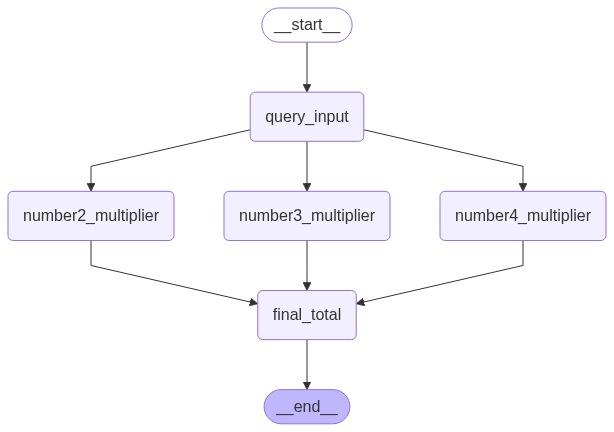

In [11]:
from IPython.display import Image, display
app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))